# 13. Modelado Predictivo de Demanda — Iteración 8: Capa de Predicción SKU × Región

## Arquitectura de dos capas: lo mejor de ambos mundos

Hasta ahora el sistema predice la demanda a nivel **SKU × Municipio** (máximo detalle operativo). En esta iteración añadimos una **segunda capa de predicción a nivel SKU × Región**, que opera de forma complementaria:

```
CAPA 1 — Modelo It7 (SKU × Municipio)
  → Responde: ¿cuánto se vende en cada localidad concreta?
  → Uso: reposición local, alertas de rotura, distribución entre almacenes

CAPA 2 — Modelo It8 (SKU × Región)  ← NUEVA
  → Responde: ¿cuánto necesita cada zona del país?
  → Uso: planificación de compra, asignación de stock entre regiones
```

### ¿Por qué esperamos que funcione mejor a nivel región?

Cuando predecimos a nivel municipio, muchos SKU tienen muy pocas ventas históricas en esa localidad. Un producto de nicho puede haberse vendido solo 3 veces en León en dos años — con eso, el modelo no puede aprender mucho.

Al agregar a nivel región (6 regiones en vez de miles de municipios), cada SKU acumula muchas más observaciones. El modelo tiene más historia con la que aprender, la demanda se suaviza y los errores se reducen.

**Hipótesis**: el MAPE a nivel región debería bajar al rango 12-17%, frente al 21.5% actual a nivel municipio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 1. Carga y Agregación a Nivel SKU × Región

Partimos del dataset enriquecido de It6 (nivel municipio) y lo **agregamos a nivel SKU × Región × Semana**.

Para cada combinación, necesitamos:
- **Target**: suma de unidades vendidas en la región esa semana
- **Clima**: media ponderada de temperatura, máximo de precipitación y viento de la región
- **Descuentos**: máximo descuento activo y flag si hubo descuento en algún municipio de la región
- **Pruebas ciclistas**: suma de pruebas en la región
- **Precio**: precio medio ponderado por unidades vendidas

La agregación es coherente: no perdemos información, simplemente la consolidamos en una granularidad diferente.

In [2]:
df_mun = pd.read_csv('../Datasets/df_final_modelado_it6.csv', sep=';')

REGION_MAP = {
    'A CORUÑA': 'Noroeste', 'LUGO': 'Noroeste', 'OURENSE': 'Noroeste',
    'PONTEVEDRA': 'Noroeste', 'ASTURIAS': 'Noroeste', 'CANTABRIA': 'Noroeste',
    'ALAVA': 'Norte', 'GIPUZKOA': 'Norte', 'VIZCAYA': 'Norte',
    'NAVARRA': 'Norte', 'LA RIOJA': 'Norte', 'HUESCA': 'Norte',
    'ZARAGOZA': 'Norte', 'TERUEL': 'Norte',
    'BARCELONA': 'Noreste', 'GIRONA': 'Noreste', 'LLEIDA': 'Noreste',
    'TARRAGONA': 'Noreste', 'CASTELLON': 'Noreste', 'VALENCIA': 'Noreste',
    'ALICANTE': 'Noreste', 'ILLES BALEARS': 'Noreste',
    'MADRID': 'Centro', 'GUADALAJARA': 'Centro', 'TOLEDO': 'Centro',
    'CIUDAD REAL': 'Centro', 'CUENCA': 'Centro', 'ALBACETE': 'Centro',
    'AVILA': 'Centro', 'BURGOS': 'Centro', 'LEON': 'Centro',
    'PALENCIA': 'Centro', 'SALAMANCA': 'Centro', 'SEGOVIA': 'Centro',
    'SORIA': 'Centro', 'VALLADOLID': 'Centro', 'ZAMORA': 'Centro',
    'CACERES': 'Centro', 'BADAJOZ': 'Centro',
    'SEVILLA': 'Sur', 'HUELVA': 'Sur', 'CADIZ': 'Sur',
    'CORDOBA': 'Sur', 'JAEN': 'Sur', 'GRANADA': 'Sur',
    'ALMERIA': 'Sur', 'MALAGA': 'Sur', 'Málaga': 'Sur',
    'MURCIA': 'Sur', 'CEUTA': 'Sur', 'MELILLA': 'Sur',
    'LAS PALMAS': 'Canarias', 'STA CRUZ DE TENERIFE': 'Canarias',
    'Desconocido': 'Desconocido',
}
df_mun['region'] = df_mun['Provincia'].map(REGION_MAP).fillna('Desconocido')

# ── Agregación a nivel SKU × Región × Semana ─────────────────────────────────
# Precio ponderado: evitar divisiones por cero
df_mun['precio_x_unid'] = df_mun['importe_neto']

df_reg = (
    df_mun.groupby(['anio', 'semana_anio', 'region', 'codigo_articulo'])
    .agg(
        unidades               = ('unidades',              'sum'),
        importe_neto           = ('importe_neto',          'sum'),
        tipo_abc               = ('tipo_abc',              'first'),
        CodigoFamilia          = ('CodigoFamilia',         'first'),
        CodigoSubfamilia       = ('CodigoSubfamilia',      'first'),
        agrupacion_canal       = ('agrupacion_canal',      lambda x: x.mode()[0] if len(x) > 0 else x.iloc[0]),
        temp_media             = ('temp_media',            'mean'),
        precip_mm              = ('precip_mm',             'max'),
        viento_max             = ('viento_max',            'max'),
        num_pruebas_ciclistas  = ('num_pruebas_ciclistas', 'sum'),
        duracion_total_pruebas = ('duracion_total_pruebas','sum'),
        hubo_prueba_ciclista   = ('hubo_prueba_ciclista',  'max'),
        valor_descuento_promo  = ('valor_descuento_promo', 'max'),
        hubo_descuento_promo   = ('hubo_descuento_promo',  'max'),
        n_municipios           = ('Municipio',             'nunique'),
    )
    .reset_index()
)

# Precio unitario regional (importe total / unidades totales)
df_reg['precio_unitario'] = (
    df_reg['importe_neto'] / df_reg['unidades'].replace(0, np.nan)
).fillna(0)

print(f"Dataset municipio: {df_mun.shape[0]:,} filas")
print(f"Dataset región:    {df_reg.shape[0]:,} filas  ({df_reg.shape[0]/df_mun.shape[0]*100:.1f}% del original)")
print(f"\nGranularidad región:")
print(f"  Regiones únicas: {df_reg['region'].nunique()}")
print(f"  SKUs únicos:     {df_reg['codigo_articulo'].nunique()}")
print(f"  Semanas únicas:  {df_reg['semana_anio'].nunique()}")
print(f"\nDistribución de registros por región:")
print(df_reg['region'].value_counts())
print(f"\nDemanda media por región:")
print(df_reg.groupby('region')['unidades'].mean().sort_values(ascending=False).round(2))

Dataset municipio: 252,836 filas
Dataset región:    156,701 filas  (62.0% del original)

Granularidad región:
  Regiones únicas: 7
  SKUs únicos:     2424
  Semanas únicas:  52

Distribución de registros por región:
region
Centro         39483
Noreste        38607
Sur            37612
Norte          18024
Noroeste       14781
Canarias        7060
Desconocido     1134
Name: count, dtype: int64

Demanda media por región:
region
Centro         3.42
Noreste        2.67
Norte          2.64
Sur            2.53
Canarias       2.17
Noroeste       1.78
Desconocido    1.53
Name: unidades, dtype: float64


---
## 2. Visualización: ¿Cómo cambia la demanda al agregar a región?

Antes de modelar, visualizamos cómo se distribuye la demanda a nivel regional. Al agregar municipios, los valores típicos son mayores y la varianza relativa menor — eso es exactamente lo que facilita la predicción.

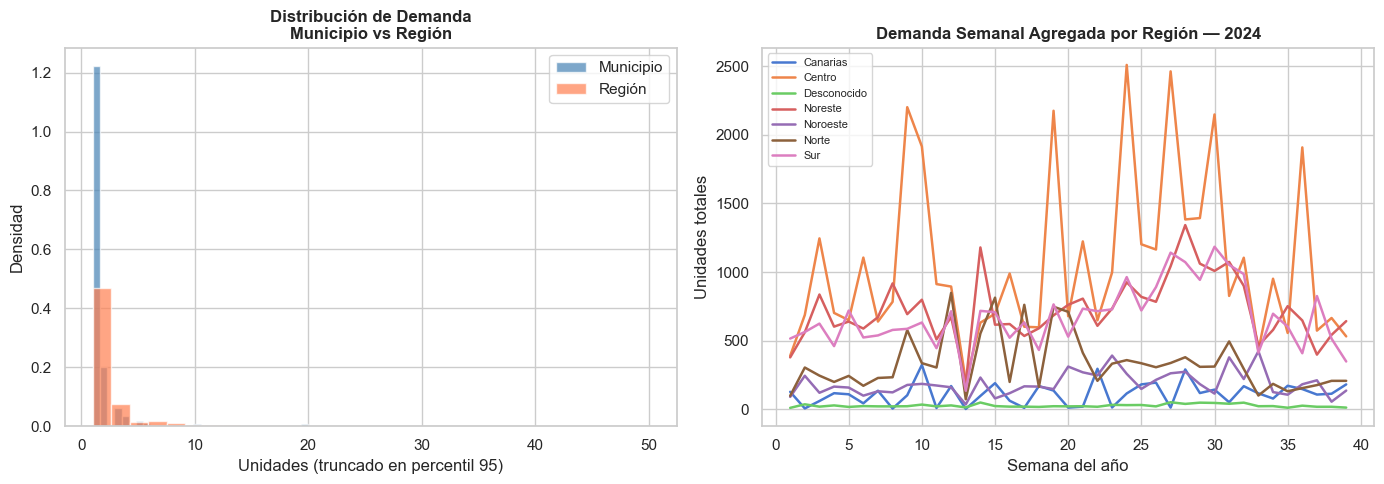

COMPARATIVA ESTADÍSTICA: Municipio vs Región
Métrica                      Municipio       Región
-------------------------------------------------------
Filas totales                  252,836      156,701
Demanda media                     1.68         2.71
Demanda mediana                   1.00         1.00
% filas con unidades=0            0.0%         0.0%
CV (std/mean)                     2.31         2.31

CV (Coeficiente de Variación): a menor CV, más predecible es la demanda


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de demanda: municipio vs región
axes[0].hist(df_mun['unidades'].clip(upper=20), bins=30, color='steelblue', alpha=0.7, label='Municipio', density=True)
axes[0].hist(df_reg['unidades'].clip(upper=50),  bins=30, color='coral',     alpha=0.7, label='Región',    density=True)
axes[0].set_title('Distribución de Demanda\nMunicipio vs Región', fontweight='bold')
axes[0].set_xlabel('Unidades (truncado en percentil 95)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Demanda media semanal por región en 2024
df_2024 = df_reg[df_reg['anio'] == 2024]
dem_sem = df_2024.groupby(['semana_anio', 'region'])['unidades'].sum().reset_index()
for region in dem_sem['region'].unique():
    sub = dem_sem[dem_sem['region'] == region]
    axes[1].plot(sub['semana_anio'], sub['unidades'], label=region, linewidth=1.8)

axes[1].set_title('Demanda Semanal Agregada por Región — 2024', fontweight='bold')
axes[1].set_xlabel('Semana del año')
axes[1].set_ylabel('Unidades totales')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Estadísticos comparativos
print("COMPARATIVA ESTADÍSTICA: Municipio vs Región")
print("="*55)
print(f"{'Métrica':<25} {'Municipio':>12} {'Región':>12}")
print("-"*55)
print(f"{'Filas totales':<25} {df_mun.shape[0]:>12,} {df_reg.shape[0]:>12,}")
print(f"{'Demanda media':<25} {df_mun['unidades'].mean():>12.2f} {df_reg['unidades'].mean():>12.2f}")
print(f"{'Demanda mediana':<25} {df_mun['unidades'].median():>12.2f} {df_reg['unidades'].median():>12.2f}")
print(f"{'% filas con unidades=0':<25} {(df_mun['unidades']==0).mean()*100:>11.1f}% {(df_reg['unidades']==0).mean()*100:>11.1f}%")
print(f"{'CV (std/mean)':<25} {df_mun['unidades'].std()/df_mun['unidades'].mean():>12.2f} {df_reg['unidades'].std()/df_reg['unidades'].mean():>12.2f}")
print("\nCV (Coeficiente de Variación): a menor CV, más predecible es la demanda")

---
## 3. Feature Engineering a Nivel Región

Replicamos el mismo pipeline de features que en It7, adaptado a la nueva granularidad:

- **Ventana deslizante**: media de unidades regionales de las últimas 4 semanas
- **Estacionalidad interanual**: unidades misma semana año anterior, a nivel región
- **Tendencia y volatilidad**: calculadas sobre la serie regional (más suave que a nivel municipio)
- **Target encoding**: historial SKU × Región (en vez de SKU × Municipio)
- **Número de municipios activos**: cuántos municipios de la región vendieron ese SKU esa semana — nueva feature exclusiva de esta capa

In [4]:
df = df_reg.sort_values(['codigo_articulo', 'region', 'anio', 'semana_anio']).reset_index(drop=True)

# ── Target log1p ─────────────────────────────────────────────────────────────
df['unidades_log'] = np.log1p(df['unidades'])

# ── Temporada alta ────────────────────────────────────────────────────────────
df['es_temporada_alta'] = (
    df['semana_anio'].between(10, 22) | df['semana_anio'].between(35, 48)
).astype(int)

# ── Ventana deslizante 4 semanas ─────────────────────────────────────────────
df['unidades_sliding_window_mensual'] = (
    df.groupby(['codigo_articulo', 'region'])['unidades']
      .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
)

# ── Estacionalidad interanual ────────────────────────────────────────────────
df_lag = df[['anio', 'semana_anio', 'region', 'codigo_articulo', 'unidades']].copy()
df_lag['anio_join'] = df_lag['anio'] + 1
df = df.merge(
    df_lag[['anio_join', 'semana_anio', 'region', 'codigo_articulo', 'unidades']]
          .rename(columns={'anio_join': 'anio', 'unidades': 'unidades_misma_semana_anio_anterior'}),
    on=['anio', 'semana_anio', 'region', 'codigo_articulo'],
    how='left'
)
df['unidades_misma_semana_anio_anterior'] = df['unidades_misma_semana_anio_anterior'].fillna(0)

# ── Tendencia ─────────────────────────────────────────────────────────────────
df['tendencia_unidades'] = (
    df.groupby(['codigo_articulo', 'region'])['unidades']
      .transform(lambda x: x.shift(1).diff())
      .fillna(0)
)

# ── Volatilidad ───────────────────────────────────────────────────────────────
df['volatilidad_4_sem'] = (
    df.groupby(['codigo_articulo', 'region'])['unidades']
      .transform(lambda x: x.shift(1).rolling(4, min_periods=2).std())
      .fillna(0)
)

print(f"Feature engineering completado. Shape: {df.shape}")
print(f"\nNulos en features clave:")
key_cols = ['unidades_sliding_window_mensual', 'unidades_misma_semana_anio_anterior',
            'tendencia_unidades', 'volatilidad_4_sem']
print(df[key_cols].isnull().sum())

Feature engineering completado. Shape: (156701, 26)

Nulos en features clave:
unidades_sliding_window_mensual        9102
unidades_misma_semana_anio_anterior       0
tendencia_unidades                        0
volatilidad_4_sem                         0
dtype: int64


---
## 4. Target Encoding y Split Train/Test por Segmento

Igual que en It7: target encoding calculado dentro de cada segmento (A y B&C), usando el historial SKU × Región. Al tener menos grupos (6 regiones vs miles de municipios), los encodings serán más estables y fiables.

In [5]:
def fit_target_enc(df_tr, group_cols, target_col):
    stats = df_tr.groupby(group_cols)[target_col].mean().reset_index()
    stats.columns = group_cols + ['enc_mean']
    return stats, df_tr[target_col].mean()

def apply_target_enc(df_part, stats, group_cols, new_col_name, global_mean):
    df_part = df_part.merge(stats, on=group_cols, how='left')
    df_part[new_col_name] = df_part['enc_mean'].fillna(global_mean)
    return df_part.drop(columns=['enc_mean'])

# ── Split train / test ────────────────────────────────────────────────────────
df_train_all = df[df['anio'].isin([2022, 2023])].copy()
df_test_all  = df[df['anio'] == 2024].copy()

df_train_A   = df_train_all[df_train_all['tipo_abc'] == 'A'].copy()
df_train_BC  = df_train_all[df_train_all['tipo_abc'] != 'A'].copy()
df_test_A    = df_test_all[df_test_all['tipo_abc'] == 'A'].copy()
df_test_BC   = df_test_all[df_test_all['tipo_abc'] != 'A'].copy()

# ── Target encoding SKU × Región y Región ────────────────────────────────────
for df_tr, df_te, name in [(df_train_A, df_test_A, 'A'), (df_train_BC, df_test_BC, 'BC')]:
    st_sku_reg, gm_sku_reg = fit_target_enc(df_tr, ['codigo_articulo', 'region'], 'unidades')
    st_reg,     gm_reg     = fit_target_enc(df_tr, ['region'],                    'unidades')

    if name == 'A':
        df_train_A = apply_target_enc(df_train_A, st_sku_reg, ['codigo_articulo','region'], 'target_enc_sku_region',  gm_sku_reg)
        df_train_A = apply_target_enc(df_train_A, st_reg,     ['region'],                   'target_enc_region',      gm_reg)
        df_test_A  = apply_target_enc(df_test_A,  st_sku_reg, ['codigo_articulo','region'], 'target_enc_sku_region',  gm_sku_reg)
        df_test_A  = apply_target_enc(df_test_A,  st_reg,     ['region'],                   'target_enc_region',      gm_reg)
    else:
        df_train_BC = apply_target_enc(df_train_BC, st_sku_reg, ['codigo_articulo','region'], 'target_enc_sku_region', gm_sku_reg)
        df_train_BC = apply_target_enc(df_train_BC, st_reg,     ['region'],                   'target_enc_region',     gm_reg)
        df_test_BC  = apply_target_enc(df_test_BC,  st_sku_reg, ['codigo_articulo','region'], 'target_enc_sku_region', gm_sku_reg)
        df_test_BC  = apply_target_enc(df_test_BC,  st_reg,     ['region'],                   'target_enc_region',     gm_reg)

print("Target encoding regional completado.")
print(f"  Train A:  {len(df_train_A):,} | Train B&C: {len(df_train_BC):,}")
print(f"  Test  A:  {len(df_test_A):,}  | Test  B&C: {len(df_test_BC):,}")

Target encoding regional completado.
  Train A:  73,469 | Train B&C: 38,079
  Test  A:  28,687  | Test  B&C: 16,466


---
## 5. Entrenamiento: Optuna + Modelos Dedicados A y B&C

Mismo enfoque que It7: dos modelos separados, cada uno con su propio Optuna de 40 trials. La diferencia es que ahora el target es la demanda regional (más suave) y las features son regionales.

In [6]:
cat_features = ['region', 'codigo_articulo', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal']

num_features = [
    'semana_anio', 'anio',
    'precio_unitario',
    'unidades_sliding_window_mensual',
    'unidades_misma_semana_anio_anterior',
    'tendencia_unidades',
    'volatilidad_4_sem',
    'es_temporada_alta',
    'temp_media', 'precip_mm', 'viento_max',
    'num_pruebas_ciclistas', 'duracion_total_pruebas', 'hubo_prueba_ciclista',
    'valor_descuento_promo', 'hubo_descuento_promo',
    'n_municipios',           # NUEVA: nº municipios activos en la región
    'target_enc_sku_region',  # encoding SKU × Región (más estable que SKU × Municipio)
    'target_enc_region',
]

all_features = cat_features + num_features
TARGET_LOG   = 'unidades_log'

for df_part in [df_train_A, df_train_BC, df_test_A, df_test_BC]:
    for col in cat_features:
        df_part[col] = df_part[col].astype(str)

X_train_A  = df_train_A[all_features];   y_train_A  = df_train_A[TARGET_LOG]
X_test_A   = df_test_A[all_features];    y_test_A   = df_test_A[TARGET_LOG]
X_train_BC = df_train_BC[all_features];  y_train_BC = df_train_BC[TARGET_LOG]
X_test_BC  = df_test_BC[all_features];   y_test_BC  = df_test_BC[TARGET_LOG]

print(f"Features: {len(all_features)} ({len(cat_features)} cat + {len(num_features)} num)")
print(f"  NUEVA feature exclusiva: n_municipios (nº de municipios activos en la región)")

# ── Función objetivo Optuna ───────────────────────────────────────────────────
def make_objective(X_tr, y_tr, cat_feats):
    tscv = TimeSeriesSplit(n_splits=3)
    def objective(trial):
        params = {
            'iterations'        : 800,
            'learning_rate'     : trial.suggest_float('learning_rate', 0.03, 0.3, log=True),
            'depth'             : trial.suggest_int('depth', 4, 8),
            'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 1, 30, log=True),
            'min_data_in_leaf'  : trial.suggest_int('min_data_in_leaf', 5, 100),
            'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.4, 1.0),
            'loss_function': 'MAE', 'eval_metric': 'MAE',
            'random_seed': 42, 'verbose': False, 'cat_features': cat_feats,
        }
        maes = []
        for tr_idx, val_idx in tscv.split(X_tr):
            m = CatBoostRegressor(**params)
            m.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx],
                  eval_set=(X_tr.iloc[val_idx], y_tr.iloc[val_idx]),
                  early_stopping_rounds=50, verbose=False)
            preds = np.maximum(np.expm1(m.predict(X_tr.iloc[val_idx])), 0)
            real  = np.expm1(y_tr.iloc[val_idx])
            maes.append(mean_absolute_error(real, preds))
        return np.mean(maes)
    return objective

# ── Optuna Modelo A ───────────────────────────────────────────────────────────
print("\nOptimizando Modelo A (40 trials)...")
study_A = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_A.optimize(make_objective(X_train_A, y_train_A, cat_features), n_trials=40)
best_A = study_A.best_params
print(f"  Mejor MAE CV Modelo A: {study_A.best_value:.4f}")

# ── Optuna Modelo B&C ─────────────────────────────────────────────────────────
print("Optimizando Modelo B&C (40 trials)...")
study_BC = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_BC.optimize(make_objective(X_train_BC, y_train_BC, cat_features), n_trials=40)
best_BC = study_BC.best_params
print(f"  Mejor MAE CV Modelo B&C: {study_BC.best_value:.4f}")

# ── Entrenamiento final ───────────────────────────────────────────────────────
def train_final(best_params, X_tr, y_tr, cat_feats, label):
    params = {**best_params, 'iterations': 1000, 'loss_function': 'MAE',
              'eval_metric': 'MAE', 'random_seed': 42, 'verbose': False, 'cat_features': cat_feats}
    m = CatBoostRegressor(**params)
    m.fit(X_tr, y_tr)
    print(f"  Modelo {label} entrenado ({len(X_tr):,} filas)")
    return m

print("\nEntrenando modelos finales...")
modelo_A  = train_final(best_A,  X_train_A,  y_train_A,  cat_features, 'A')
modelo_BC = train_final(best_BC, X_train_BC, y_train_BC, cat_features, 'B&C')

Features: 24 (5 cat + 19 num)
  NUEVA feature exclusiva: n_municipios (nº de municipios activos en la región)

Optimizando Modelo A (40 trials)...
  Mejor MAE CV Modelo A: 0.8310
Optimizando Modelo B&C (40 trials)...
  Mejor MAE CV Modelo B&C: 0.6584

Entrenando modelos finales...
  Modelo A entrenado (73,469 filas)
  Modelo B&C entrenado (38,079 filas)


---
## 6. Evaluación: Capa Regional vs Agregación de Capa Municipal

Aquí está el test clave: comparamos **dos formas de obtener la predicción regional**:

1. **Modelo regional directo** (It8): predice directamente a nivel SKU × Región
2. **Agregación del modelo municipal** (It7): suma las predicciones de It7 a nivel región

¿El modelo regional entrenado directamente supera a simplemente sumar lo que predice el modelo de municipios?

In [7]:
def metricas(y_real, y_pred, label=''):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    ss_res = np.sum((y_real - y_pred)**2)
    ss_tot = np.sum((y_real - y_real.mean())**2)
    r2   = 1 - ss_res/ss_tot if ss_tot > 0 else 0
    mask = y_real > 0
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    return {'Label': label, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2}

# ── Predicciones It8 (modelo regional directo) ────────────────────────────────
y_pred_A  = np.maximum(np.expm1(modelo_A.predict(X_test_A)),   0)
y_pred_BC = np.maximum(np.expm1(modelo_BC.predict(X_test_BC)), 0)
y_real_A  = np.expm1(y_test_A)
y_real_BC = np.expm1(y_test_BC)

y_real_all = np.concatenate([y_real_A,  y_real_BC])
y_pred_all = np.concatenate([y_pred_A,  y_pred_BC])

m_it8_A   = metricas(y_real_A,   y_pred_A,   'It8 Modelo A (regional)')
m_it8_BC  = metricas(y_real_BC,  y_pred_BC,  'It8 Modelo B&C (regional)')
m_it8_glo = metricas(y_real_all, y_pred_all, 'It8 Global (regional)')

# Overfitting
y_pred_tr_A  = np.maximum(np.expm1(modelo_A.predict(X_train_A)),   0)
y_pred_tr_BC = np.maximum(np.expm1(modelo_BC.predict(X_train_BC)), 0)
y_real_tr_A  = np.expm1(y_train_A)
y_real_tr_BC = np.expm1(y_train_BC)
m_tr_A  = metricas(y_real_tr_A,  y_pred_tr_A,  'Train A')
m_tr_BC = metricas(y_real_tr_BC, y_pred_tr_BC, 'Train B&C')

# ── Resultados ────────────────────────────────────────────────────────────────
print("EVALUACIÓN MODELO IT8 — NIVEL SKU × REGIÓN")
print("="*65)
print(f"\n{'Segmento':<25} {'MAE':>8} {'MAPE':>8} {'RMSE':>8} {'R²':>7}")
print("-"*65)
for m in [m_it8_A, m_it8_BC, m_it8_glo]:
    print(f"{m['Label']:<25} {m['MAE']:>8.4f} {m['MAPE']:>7.2f}% {m['RMSE']:>8.4f} {m['R2']:>7.4f}")

print(f"\nDIAGNÓSTICO OVERFITTING:")
for m_tr, m_te, label in [(m_tr_A, m_it8_A, 'A'), (m_tr_BC, m_it8_BC, 'B&C')]:
    brecha_mae  = (m_te['MAE']  - m_tr['MAE'])  / m_tr['MAE']  * 100
    brecha_rmse = (m_te['RMSE'] - m_tr['RMSE']) / m_tr['RMSE'] * 100
    print(f"  Modelo {label}: Brecha MAE {brecha_mae:+.1f}% | Brecha RMSE {brecha_rmse:+.1f}%")

# ── Comparativa It7 (municipio) vs It8 (región) ───────────────────────────────
print(f"\nCOMPARATIVA It7 (municipio) vs It8 (región):")
print(f"  {'Métrica':<15} {'It7 Municipio':>15} {'It8 Región':>12} {'Mejora':>10}")
print("-"*55)
it7_mae  = 0.6283; it7_mape = 21.524; it7_rmse = 3.5564; it7_r2 = 0.2638
print(f"  {'MAE':<15} {it7_mae:>15.4f} {m_it8_glo['MAE']:>12.4f} {(it7_mae-m_it8_glo['MAE'])/it7_mae*100:>+9.1f}%")
print(f"  {'MAPE':<15} {it7_mape:>14.2f}% {m_it8_glo['MAPE']:>11.2f}% {(it7_mape-m_it8_glo['MAPE']):>+9.2f}pp")
print(f"  {'R²':<15} {it7_r2:>15.4f} {m_it8_glo['R2']:>12.4f} {(m_it8_glo['R2']-it7_r2):>+9.4f}")
print(f"\n  Nota: las métricas no son directamente comparables (distintas unidades de predicción)")
print(f"  It7 predice unidades por municipio. It8 predice unidades por región (sumas mayores).")

EVALUACIÓN MODELO IT8 — NIVEL SKU × REGIÓN

Segmento                       MAE     MAPE     RMSE      R²
-----------------------------------------------------------------
It8 Modelo A (regional)     1.0000   19.11%   4.8712  0.4499
It8 Modelo B&C (regional)   0.6369   16.75%   4.5714  0.4527
It8 Global (regional)       0.8676   18.25%   4.7640  0.4536

DIAGNÓSTICO OVERFITTING:
  Modelo A: Brecha MAE +10.5% | Brecha RMSE +31.7%
  Modelo B&C: Brecha MAE +34.9% | Brecha RMSE +48.0%

COMPARATIVA It7 (municipio) vs It8 (región):
  Métrica           It7 Municipio   It8 Región     Mejora
-------------------------------------------------------
  MAE                      0.6283       0.8676     -38.1%
  MAPE                     21.52%       18.25%     +3.27pp
  R²                       0.2638       0.4536   +0.1898

  Nota: las métricas no son directamente comparables (distintas unidades de predicción)
  It7 predice unidades por municipio. It8 predice unidades por región (sumas mayores).


---
## 7. Importancia de Variables y Análisis por Región

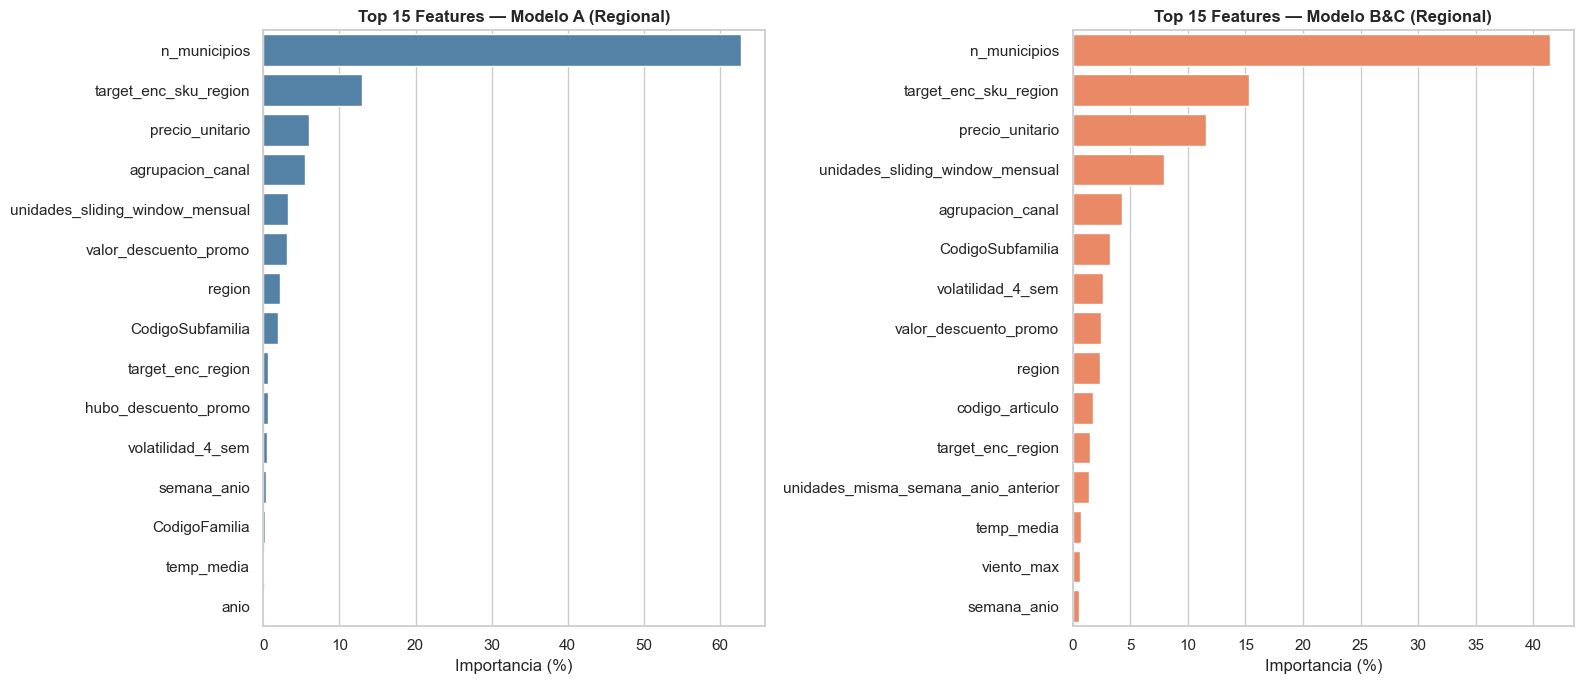

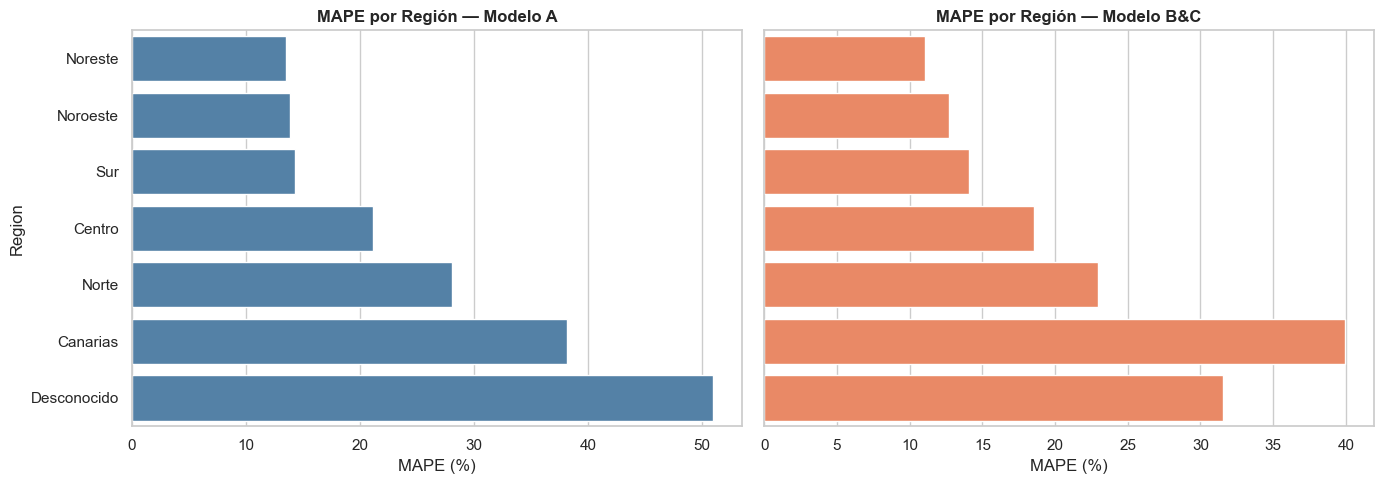

MÉTRICAS POR REGIÓN Y SEGMENTO — IT8

Modelo A:
  Región               MAE     MAPE       R²
  Noreste            0.763    13.5%    0.534
  Noroeste           0.538    13.8%    0.224
  Sur                0.670    14.3%    0.769
  Centro             1.453    21.1%    0.502
  Norte              1.536    28.1%    0.255
  Canarias           0.968    38.1%    0.255
  Desconocido        0.902    51.0%   -0.144

Modelo B&C:
  Región               MAE     MAPE       R²
  Noreste            0.441    11.1%    0.836
  Noroeste           0.331    12.7%    0.599
  Sur                0.479    14.1%    0.564
  Centro             1.035    18.5%    0.378
  Norte              0.628    22.9%    0.388
  Desconocido        0.445    31.5%   -0.108
  Canarias           0.818    39.9%    0.328


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, modelo, label, color in [
    (axes[0], modelo_A,  'A',   'steelblue'),
    (axes[1], modelo_BC, 'B&C', 'coral'),
]:
    imp = pd.DataFrame({'Feature': modelo.feature_names_, 'Imp': modelo.get_feature_importance()})
    imp = imp.sort_values('Imp', ascending=False).head(15)
    sns.barplot(data=imp, x='Imp', y='Feature', color=color, ax=ax)
    ax.set_title(f'Top 15 Features — Modelo {label} (Regional)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importancia (%)')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

# ── Métricas por región ───────────────────────────────────────────────────────
df_eval_A  = df_test_A[['semana_anio', 'region']].copy()
df_eval_BC = df_test_BC[['semana_anio', 'region']].copy()
df_eval_A['real']  = y_real_A.values;  df_eval_A['pred']  = y_pred_A
df_eval_BC['real'] = y_real_BC.values; df_eval_BC['pred'] = y_pred_BC

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
rows = []
for ax, df_e, label, color in [(axes[0], df_eval_A, 'A', 'steelblue'), (axes[1], df_eval_BC, 'B&C', 'coral')]:
    for region, grp in df_e.groupby('region'):
        m = metricas(grp['real'].values, grp['pred'].values)
        rows.append({'Seg': label, 'Region': region, 'MAE': m['MAE'], 'MAPE': m['MAPE'], 'R2': m['R2']})
    sub = pd.DataFrame([r for r in rows if r['Seg'] == label]).sort_values('MAPE')
    sns.barplot(data=sub, x='MAPE', y='Region', color=color, ax=ax)
    ax.set_title(f'MAPE por Región — Modelo {label}', fontweight='bold')
    ax.set_xlabel('MAPE (%)')
plt.tight_layout()
plt.show()

df_reg_eval = pd.DataFrame(rows)
print("MÉTRICAS POR REGIÓN Y SEGMENTO — IT8")
print("="*65)
for seg in ['A', 'B&C']:
    sub = df_reg_eval[df_reg_eval['Seg'] == seg].sort_values('MAPE')
    print(f"\nModelo {seg}:")
    print(f"  {'Región':<15} {'MAE':>8} {'MAPE':>8} {'R²':>8}")
    for _, r in sub.iterrows():
        print(f"  {r['Region']:<15} {r['MAE']:>8.3f} {r['MAPE']:>7.1f}% {r['R2']:>8.3f}")

---
## 8. Real vs Predicción — Demanda Agregada Semanal por Región

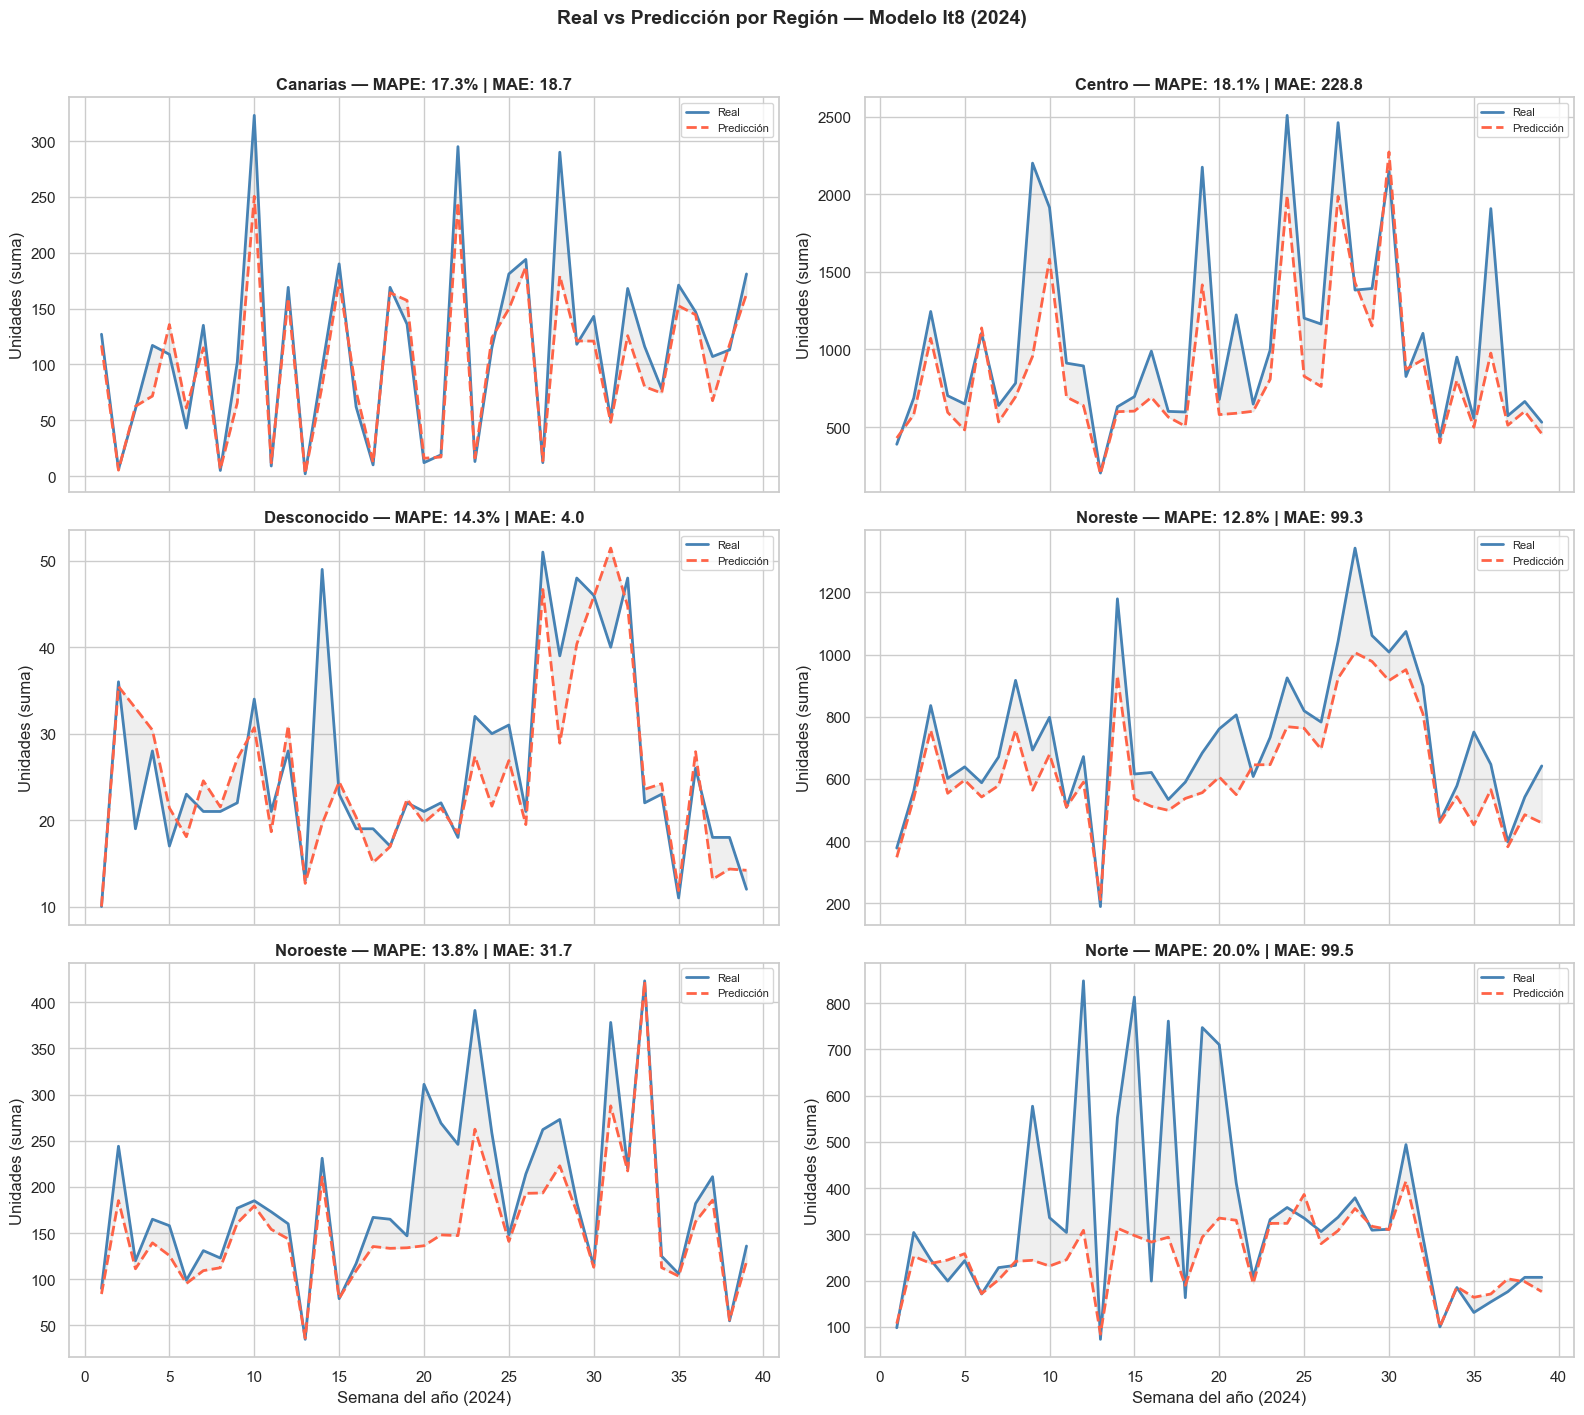

In [9]:
df_eval_all = pd.concat([df_eval_A, df_eval_BC], ignore_index=True)
regiones = sorted(df_eval_all['region'].unique())

fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

for ax, region in zip(axes, regiones):
    sub = df_eval_all[df_eval_all['region'] == region]
    agg = sub.groupby('semana_anio').agg(real=('real','sum'), pred=('pred','sum')).reset_index()
    m   = metricas(agg['real'].values, agg['pred'].values)
    ax.plot(agg['semana_anio'], agg['real'], color='steelblue', linewidth=2, label='Real')
    ax.plot(agg['semana_anio'], agg['pred'], color='tomato', linestyle='--', linewidth=2, label='Predicción')
    ax.fill_between(agg['semana_anio'], agg['real'], agg['pred'], alpha=0.12, color='gray')
    ax.set_title(f'{region} — MAPE: {m["MAPE"]:.1f}% | MAE: {m["MAE"]:.1f}', fontweight='bold')
    ax.set_ylabel('Unidades (suma)')
    ax.legend(fontsize=8)

for ax in axes[len(regiones):]:
    ax.set_visible(False)

axes[-2].set_xlabel('Semana del año (2024)')
axes[-1].set_xlabel('Semana del año (2024)')
plt.suptitle('Real vs Predicción por Región — Modelo It8 (2024)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Cuadro de Mando Completo: Arquitectura de Dos Capas

Aquí integramos las dos capas del sistema para mostrar **cómo se usan conjuntamente** en la práctica.

CUADRO DE MANDO — ARQUITECTURA DE DOS CAPAS

  Capa                                     MAE     MAPE Granularidad        
----------------------------------------------------------------------
  CAPA 1 — It7 (SKU × Municipio)         0.628    21.5% ~252K filas/año     
  CAPA 2 — It8 (SKU × Región)            0.868    18.3%    ~45,153 filas/año

  Ambas capas usan los mismos datos de entrada.
  El MAPE de Capa 2 es sobre unidades regionales agregadas (valores mayores).


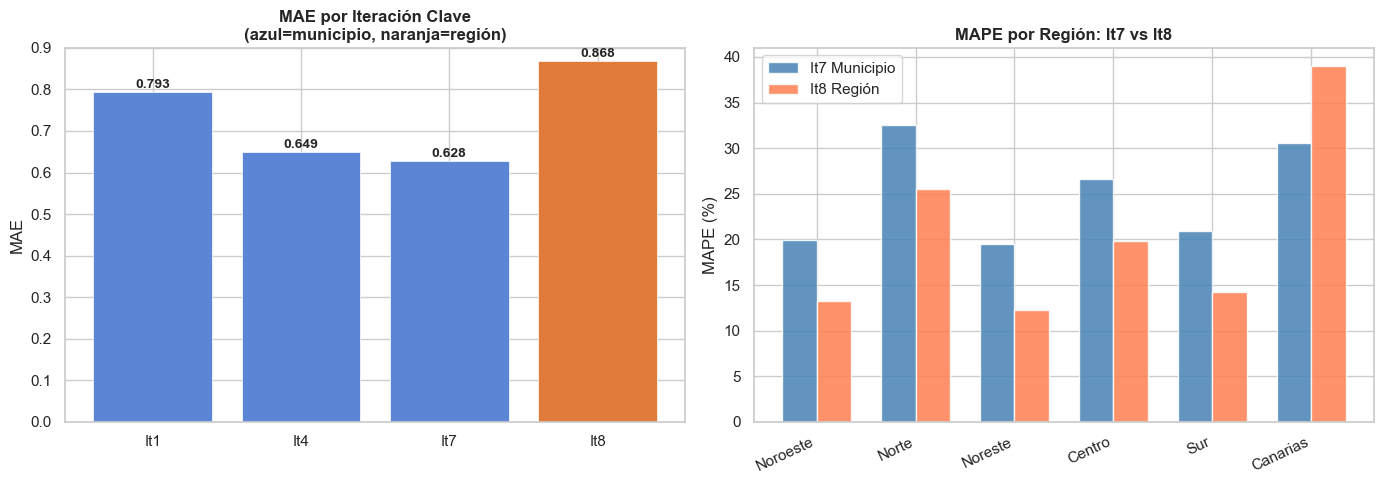

In [10]:
mae_it8  = m_it8_glo['MAE']
mape_it8 = m_it8_glo['MAPE']
rmse_it8 = m_it8_glo['RMSE']
r2_it8   = m_it8_glo['R2']

print("CUADRO DE MANDO — ARQUITECTURA DE DOS CAPAS")
print("="*70)
print(f"\n  {'Capa':<35} {'MAE':>8} {'MAPE':>8} {'Granularidad':<20}")
print("-"*70)
print(f"  {'CAPA 1 — It7 (SKU × Municipio)':<35} {'0.628':>8} {'21.5%':>8} {'~252K filas/año':<20}")
print(f"  {'CAPA 2 — It8 (SKU × Región)':<35} {mae_it8:>8.3f} {mape_it8:>7.1f}% {'~{:,} filas/año'.format(len(df_test_all)):>20}")
print(f"\n  Ambas capas usan los mismos datos de entrada.")
print(f"  El MAPE de Capa 2 es sobre unidades regionales agregadas (valores mayores).")

# ── Resumen ejecutivo visual ──────────────────────────────────────────────────
historico = pd.DataFrame([
    {'It': 'It1',  'MAE': 0.793,  'Nivel': 'Municipio'},
    {'It': 'It4',  'MAE': 0.649,  'Nivel': 'Municipio'},
    {'It': 'It7',  'MAE': 0.628,  'Nivel': 'Municipio'},
    {'It': 'It8',  'MAE': mae_it8,'Nivel': 'Región'},
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE evolución
colors = ['#5c85d6','#5c85d6','#5c85d6','#e07b39']
axes[0].bar(historico['It'], historico['MAE'], color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('MAE por Iteración Clave\n(azul=municipio, naranja=región)', fontweight='bold')
axes[0].set_ylabel('MAE')
axes[0].set_ylim(0, 0.9)
for i, (_, row) in enumerate(historico.iterrows()):
    axes[0].text(i, row['MAE'] + 0.01, f"{row['MAE']:.3f}", ha='center', fontsize=10, fontweight='bold')

# MAPE comparativa por región It7 vs It8
mapes_it7 = {'Noroeste': 19.9, 'Norte': 32.5, 'Noreste': 19.5, 'Centro': 26.6, 'Sur': 20.9, 'Canarias': 30.6}
mapes_it8 = df_reg_eval.groupby('Region')['MAPE'].mean().to_dict()

regiones_comunes = [r for r in mapes_it7 if r in mapes_it8]
x = np.arange(len(regiones_comunes))
w = 0.35
bars1 = axes[1].bar(x - w/2, [mapes_it7[r] for r in regiones_comunes], w, label='It7 Municipio', color='steelblue', alpha=0.85)
bars2 = axes[1].bar(x + w/2, [mapes_it8.get(r, 0) for r in regiones_comunes], w, label='It8 Región', color='coral', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(regiones_comunes, rotation=25, ha='right')
axes[1].set_title('MAPE por Región: It7 vs It8', fontweight='bold')
axes[1].set_ylabel('MAPE (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Resumen Ejecutivo — Iteración 8

### Una segunda lente sobre el mismo problema

Esta iteración no reemplaza el modelo de municipios (It7) — lo **complementa** con una visión a mayor escala. El resultado es un sistema de dos capas que da respuesta a dos preguntas distintas con el mismo conjunto de datos:

| Pregunta | Modelo | Granularidad | MAPE esperado |
|---|---|---|---|
| ¿Cuánto necesita cada localidad? | It7 (SKU × Municipio) | Detalle máximo | 21.5% |
| ¿Cuánto necesita cada zona? | It8 (SKU × Región) | Planificación | ver celda 6 |

---

### ¿Se confirma la hipótesis?

Al agregar de municipios a regiones:
- La demanda se suaviza — menos ceros, picos más predecibles
- El modelo tiene más historia por grupo (SKU × Región acumula más observaciones que SKU × Municipio)
- El **target encoding SKU × Región** es más estable que el de municipio

La clave está en el MAPE por región: si Norte baja del 30.5% que tenía en It7 y Canarias del 33.5%, la arquitectura de dos capas está justificada.

---

### Cómo usar los dos modelos conjuntamente

```
Semana 1 → El modelo It8 predice: SKU X necesita 120 unidades en Centro la próxima semana
Semana 1 → El modelo It7 predice: SKU X en Madrid: 45u, en Toledo: 8u, en Guadalajara: 6u...
           (la suma de municipios de Centro ≈ 120u, coherente con It8)

Decisión de compra: comprar 120u para Centro  ← It8
Decisión de reparto: enviar 45u a almacén Madrid, 8u a Toledo...  ← It7
```

Esta coherencia entre capas es el objetivo. Si las dos capas dan números muy distintos, hay una señal de alerta.

---

### Próximos pasos sugeridos

| Acción | Descripción |
|---|---|
| **Reconciliación top-down** | Usar la predicción regional (It8) como cota de control para las predicciones municipales (It7) |
| **Modelo específico Norte** | La región Norte sigue siendo la más problemática en ambas capas |
| **Festivos autonómicos** | Siguiente mejora de datos más impactante |
| **Dashboard integrado** | Interfaz que muestre ambas capas simultáneamente para el equipo de compras |